<a href="https://colab.research.google.com/github/sudha-v/ipynp-samples/blob/master/Session_File1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compare between Python Data visualization Libraries.

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import seaborn as sn
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

### Read file

In [3]:
from google.colab import files
uploaded = files.upload()

Saving SessionData.xlsx to SessionData.xlsx


In [4]:
df = pd.read_excel('SessionData.xlsx')
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2023-11-08,2023-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2023-11-08,2023-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2023-06-12,2023-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2022-10-11,2022-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2022-10-11,2022-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

#### Get sales at Category level and visualize using MatplotLib

In [9]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


<Axes: xlabel='Category'>

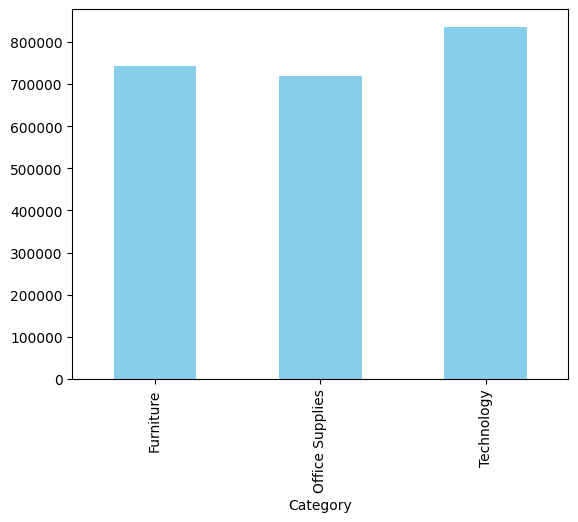

In [8]:
category_sales.plot(kind='bar', color='skyblue')

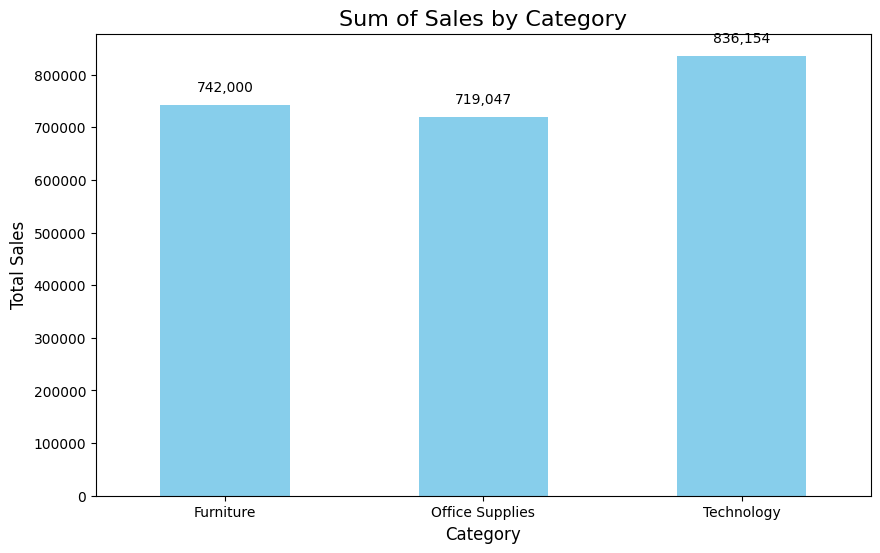

In [10]:
plt.figure(figsize=(10, 6))

ax = category_sales.plot(kind='bar', color='skyblue')

plt.title('Sum of Sales by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0)

# Add labels on the bars
for i, v in enumerate(category_sales):
    ax.text(i, v + 20000, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.show()

#### Get profit for all sub-category and visualize using Seaborn Library

In [12]:
subcategory_profits = (df.groupby('Sub-Category')
                       ['Profit'].sum().sort_values(ascending=False))

<Axes: ylabel='Sub-Category'>

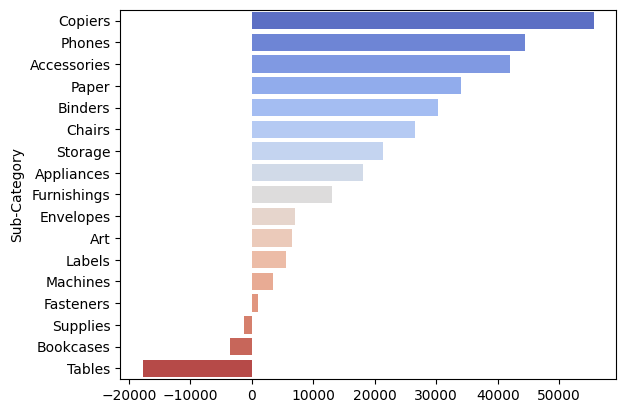

In [13]:
sn.barplot(x=subcategory_profits.values, y=subcategory_profits.index, palette='coolwarm')

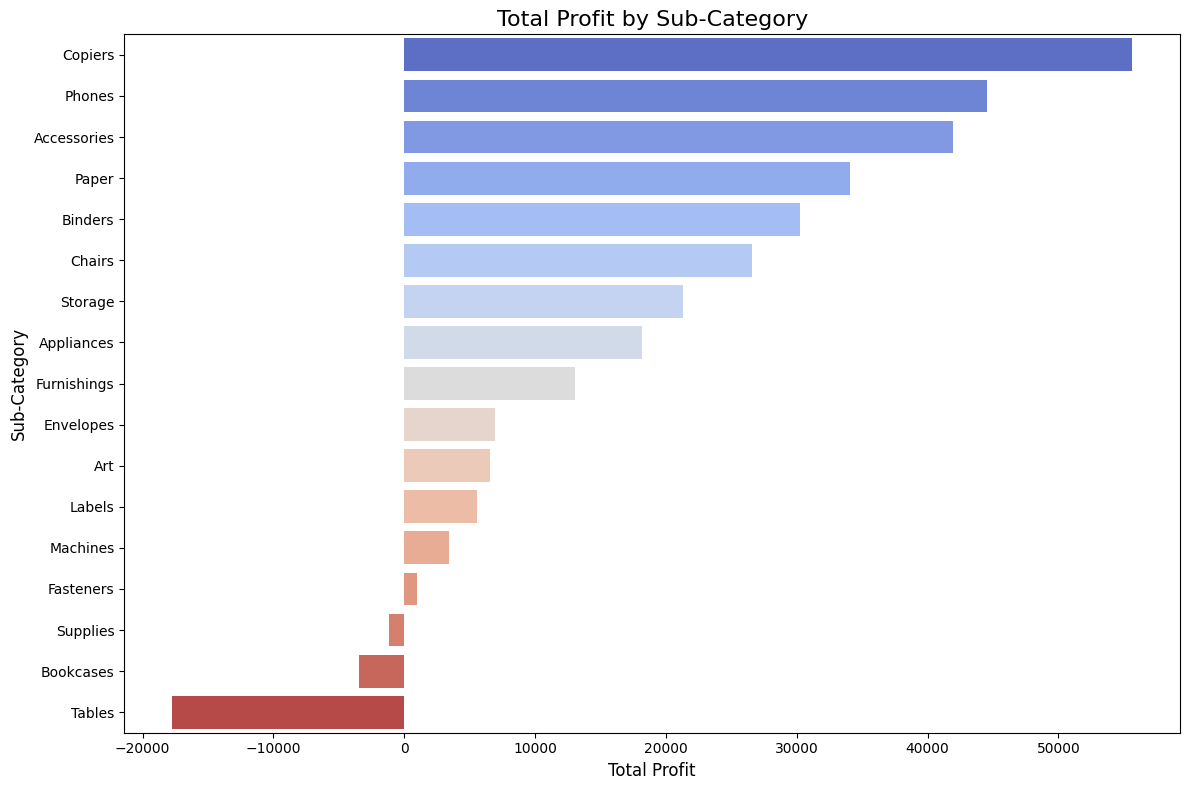

In [14]:
plt.figure(figsize=(12, 8))
sn.barplot(x=subcategory_profits.values, y=subcategory_profits.index, palette='coolwarm')

plt.title('Total Profit by Sub-Category', fontsize=16)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

#### Check relationship between Sales and Profit using Plotly

In [15]:
fig = px.scatter(df, x='Sales', y='Profit', title='Sales vs Profit Scatter Plot')
fig.show()

In [16]:
fig = px.scatter_3d(df, x='Sales', y='Discount', z='Profit',
              color='Category')
fig.show()

# Build Plotly Dashboard

In [17]:
!pip install dash
!pip install dash_bootstrap_components

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.4 MB/s eta 0:00:00


## Understanding of DASH components and Layout

In [18]:
from dash import Dash, html, dcc, Output, Input
import dash_bootstrap_components as dbc

### Inialize the DASH application

In [41]:
app = Dash(__name__, external_stylesheets=[dbc.themes.SOLAR])

### Create Layout

In [42]:
app.layout = html.Div([
    dbc.Container([
        html.H1(children="Retail Data analysis Dashboard",
                style={'color': 'white', 'textAlign': 'center'}),
    ])
])

### Run Dashboard Application

In [43]:
from google.colab import output
app.run(port=8050, debug=False)
output.serve_kernel_port_as_iframe(8050)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:15:43] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:15:43] "GET /_dash-component-suites/dash/deps/react@18.v4_0_0m1774090394.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:15:43] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_0_0m1774090394.12.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:15:43] "GET /_dash-component-suites/dash_bootstrap_components/_components/dash_bootstrap_components.v2_0_4m1774090402.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:15:43] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1774090394.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:15:43] "GET /_dash-component-suites/dash/dcc/dash_core_

<IPython.core.display.Javascript object>

## Let us add a Graph to the Dashboard Layout

#### Aggregate Profit values acorss Subcategories

In [49]:
groupdf = df.groupby(['Sub-Category'], as_index=False).agg({'Profit':'sum'})

groupdf = groupdf.sort_values(by=['Profit'], ascending=True)

In [50]:
fig = px.bar(groupdf, x="Profit", y="Sub-Category",
             color="Profit", template='simple_white',
             # Use a diverging palette
             color_continuous_scale=px.colors.diverging.RdYlBu,
             # Set the midpoint
             color_continuous_midpoint=100)

In [51]:
app.layout = html.Div([
    dbc.Container([
        html.H1(children="Retail Data analysis Dashboard",
                style={'color': 'white', 'textAlign': 'center'}),

        html.Div(dcc.Graph(figure=fig)),
    ])
])

### Run Dashboard Application

In [52]:
from google.colab import output
app.run(port=8050, debug=False)
output.serve_kernel_port_as_window(8050)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:20:58] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:20:58] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_0_0m1774090394.12.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:20:58] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1774090394.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:20:58] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_0_0m1774090394.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:20:58] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_0_0m1774090394.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:20:58] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_0_0m177409039

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

## Let us add a Interactive Element to Dashboard

In [53]:
app.layout = html.Div([
    dbc.Container([
        html.H1(children="Retail Data analysis Dashboard",
                style={'color': 'white', 'textAlign': 'center'}),

        html.Div(
            dcc.Dropdown(df.Region.unique(), id='Region')),

        html.Br(),

        html.Div(dcc.Graph(figure=fig)),
    ])
])

### Run Dashboard Application

In [54]:
from google.colab import output
app.run(port=8050, debug=False)
output.serve_kernel_port_as_window(8050)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:21:20] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:21:20] "GET /_dash-component-suites/dash_bootstrap_components/_components/dash_bootstrap_components.v2_0_4m1774090402.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:21:20] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1774090394.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:21:20] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_0_0m1774090394.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:21:20] "GET /_dash-component-suites/dash/dash_table/bundle.v7_0_0m1774090394.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:21:20] "GET /_dash-component-suites/dash/html/dash_html_c

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

## Let us make components interact

In [55]:
app.layout = html.Div([
    dbc.Container([
        html.H1(children="Retail Data analysis Dashboard",
                style={'color': 'white', 'textAlign': 'center'}),

        html.Div(
            dcc.Dropdown(df.Region.unique(), id='Region')),

        html.Br(),

        html.Div(
            dcc.Graph(id='BarGraph')),
    ])
])

### Callback

In [56]:
# Callback allows components to interact
@app.callback(
    Output('BarGraph', 'figure'),
    Input('Region', 'value')
)
# function arguments come from the component property of the Input
def update_graph(regionselected):
    fig = ''

    filterdata = df[df['Region'] == regionselected]
    groupdf = filterdata.groupby(['Sub-Category'], as_index=False).agg({'Profit':'sum'})
    groupdf = groupdf.sort_values(by=['Profit'], ascending=True)

    fig = px.bar(groupdf, x="Profit", y="Sub-Category",
             color="Profit", template='simple_white',
             # Use a diverging palette
             color_continuous_scale=px.colors.diverging.RdYlBu,
             # Set the midpoint
             color_continuous_midpoint=100)

    return fig

### Run Dashboard Application

In [57]:
from google.colab import output
app.run(port=8050, debug=False)
output.serve_kernel_port_as_window(8050)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:23:15] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:23:15] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_0_0m1774090394.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:23:15] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_0_0m1774090394.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:23:15] "GET /_dash-component-suites/dash/deps/react@18.v4_0_0m1774090394.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:23:15] "GET /_dash-component-suites/dash/html/dash_html_components.v4_0_0m1774090394.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:23:15] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

# Task
I will update the four instances of `output.serve_kernel_port_as_window(8050)` to `output.serve_kernel_port_as_iframe(8050)` in the specified cells, re-run those cells to launch the Dash dashboard, and then confirm that the dashboard is accessible and functioning correctly within the Colab output.

Starting with the first instance:
1. **Update Dashboard Run Code (First Instance)**: Modify the code in cell `zN-_evdEUaHs` to use `output.serve_kernel_port_as_iframe(8050)` instead of `output.serve_kernel_port_as_window(8050)`.

## Update Dashboard Run Code (First Instance)

### Subtask:
Modify the code in cell `zN-_evdEUaHs` to use `output.serve_kernel_port_as_iframe(8050)` instead of `output.serve_kernel_port_as_window(8050)`.


## Update Dashboard Run Code (First Instance)

### Subtask:
Modify the code in cell `zN-_evdEUaHs` to use `output.serve_kernel_port_as_iframe(8050)` instead of `output.serve_kernel_port_as_window(8050)`.


## Run Dashboard Application (First Instance)

### Subtask:
Re-run cell `zN-_evdEUaHs` to launch the Dash dashboard with the updated `output.serve_kernel_port_as_iframe` function.


**Reasoning**:
The subtask instructs to re-run cell `zN-_evdEUaHs` after the modification. This step will execute the updated code to launch the Dash dashboard as an iframe.



In [23]:
from google.colab import output
app.run(port=8050, debug=False)
output.serve_kernel_port_as_iframe(8050)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:06:37] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:06:37] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1774090394.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:06:37] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_0_0m1774090394.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:06:37] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_0_0m1774090394.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:06:37] "GET /_dash-component-suites/dash/html/dash_html_components.v4_0_0m1774090394.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Mar/2026 11:06:38] "GET /_dash-component-suites/dash/dash_table/bundle.v7_0_0m1774

<IPython.core.display.Javascript object>